# Data Collection and Feature Engineering for Financial Time Series Forecasting

## Objective

The purpose of this notebook is to construct a high-quality dataset for financial time series forecasting. Rather than focusing immediately on complex deep learning architectures, this notebook emphasizes data quality, feature engineering, and statistical preprocessing.

Financial markets are inherently noisy, non-stationary, and influenced by numerous external factors. Consequently, the predictive performance of a model often depends more on the quality of its input features than on the complexity of the model itself.

This notebook will:

- Download historical stock market data
- Clean and validate the dataset
- Perform exploratory data analysis
- Engineer price, volume, volatility, and candlestick features
- Generate prediction targets
- Save the processed dataset for subsequent notebooks

Future notebooks will build progressively on this foundation by introducing baseline machine learning models, custom Transformer architectures, feedback attention refinement, market regime detection, and realistic backtesting.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from tqdm import tqdm

import yfinance as yf

from ta import add_all_ta_features

from sklearn.preprocessing import StandardScaler

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [4]:
CONFIG = {

    "ticker": "AAPL",

    "start_date": "2015-01-01",

    "end_date": "2025-12-31",

    "prediction_horizon": 5,

    "rolling_window": 20,

    "output_path": "./",

}

## Download Historical Market Data

Historical OHLCV (Open, High, Low, Close, Volume) data is downloaded from Yahoo Finance.

The downloaded dataset forms the primary source of information for subsequent feature engineering.

Columns:

- Open
- High
- Low
- Close
- Volume

In [8]:
import yfinance as yf

df = yf.download(
    CONFIG["ticker"],
    start=CONFIG["start_date"],
    end=CONFIG["end_date"],
    auto_adjust=True,
    progress=False,
    group_by="column"
)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()

df.head()

Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.192610,24.659512,23.754473,24.648447,212818400
1,2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2,2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
3,2015-01-07,23.842978,23.942553,23.610632,23.721273,160423600
4,2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000


In [9]:
print(f"Rows      : {len(df)}")
print(f"Columns   : {len(df.columns)}")

print("\nColumn Types\n")
print(df.dtypes)

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

Rows      : 2765
Columns   : 6

Column Types

Price
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
dtype: object

Missing Values

Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate Rows : 0


In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Price,,,,,,,,
Date,2765,2020-06-29 19:22:56,2015-01-02 00:00:00,2017-09-29 00:00:00,2020-06-30 00:00:00,2023-03-29 00:00:00,2025-12-30 00:00:00,NaN
Close,2765.0,106.067728,20.565872,36.580723,88.302399,168.319778,285.659271,74.130173
High,2765.0,107.119518,20.868643,36.985166,89.268174,169.717637,288.084759,74.836666
Low,2765.0,104.911608,20.367818,36.239433,87.140528,166.816741,282.774617,73.343359
Open,2765.0,105.970905,20.488469,36.586574,88.207976,168.05456,285.669263,74.050475
Volume,2765.0,111429771.066908,17910600.0,64902300.0,94550000.0,137298000.0,648825200.0,68035920.907984


In [11]:
df.columns.name = None
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


# Exploratory Data Analysis

Before engineering features, it is important to understand the statistical properties of the dataset.

In this section we will:

- Visualize historical price movement
- Plot trading volume
- Examine daily returns
- Measure rolling volatility
- Identify possible anomalies

EDA often reveals trends, structural breaks, volatility clustering, and outliers that influence model performance.

In [12]:
fig = go.Figure()

fig.add_trace(
    go.Candlestick(
        x=df["Date"],
        open=df["Open"],
        high=df["High"],
        low=df["Low"],
        close=df["Close"],
        name="Price"
    )
)

fig.update_layout(
    title=f"{CONFIG['ticker']} Price History",
    xaxis_title="Date",
    yaxis_title="Price ($)",
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    height=700
)

fig.show()

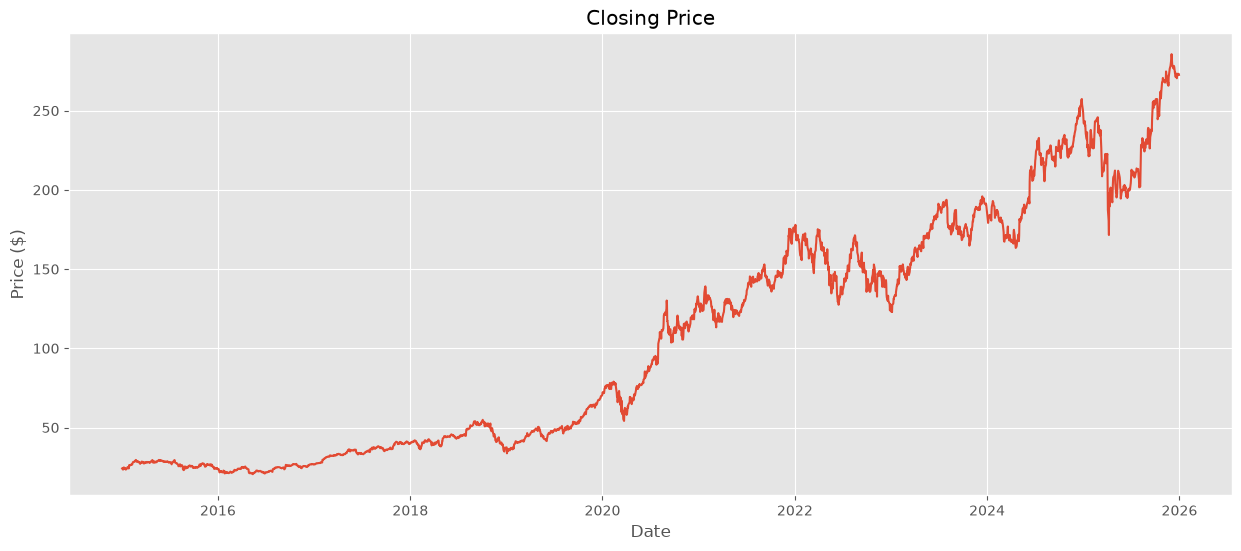

In [13]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Close"], linewidth=1.5)

plt.title("Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.show()

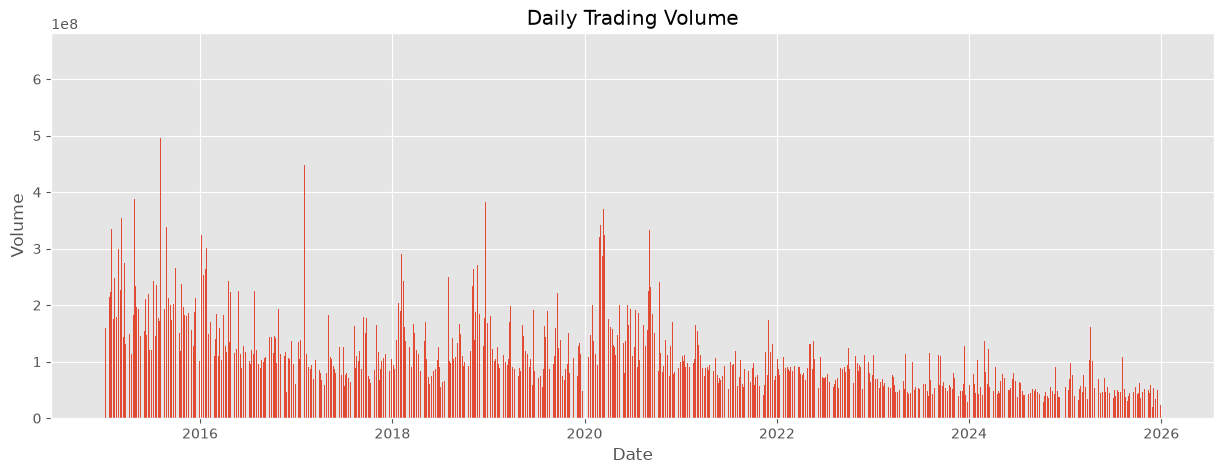

In [14]:
plt.figure(figsize=(15,5))

plt.bar(df["Date"], df["Volume"])

plt.title("Daily Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.show()

In [15]:
df["Daily_Return"] = df["Close"].pct_change()

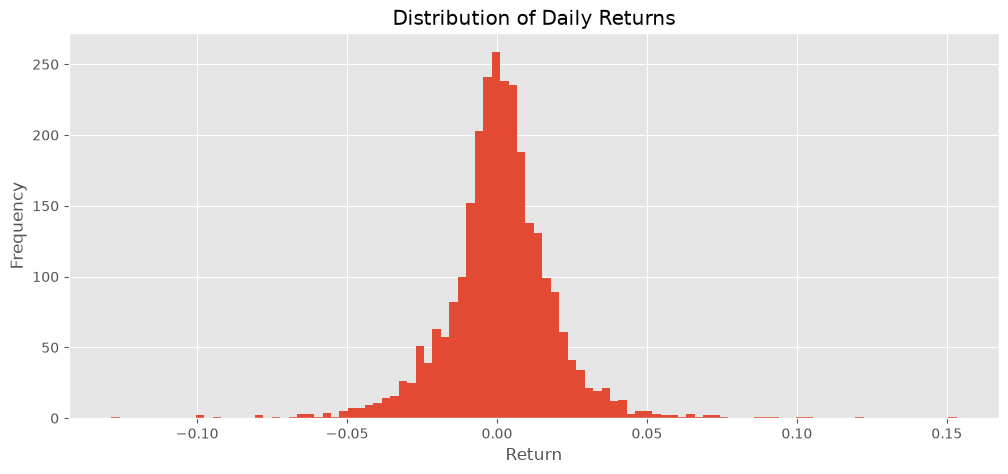

In [16]:
plt.figure(figsize=(12,5))

plt.hist(df["Daily_Return"].dropna(), bins=100)

plt.title("Distribution of Daily Returns")

plt.xlabel("Return")

plt.ylabel("Frequency")

plt.show()

In [17]:
window = CONFIG["rolling_window"]

df["Rolling_Volatility"] = (
    df["Daily_Return"]
    .rolling(window)
    .std()
)

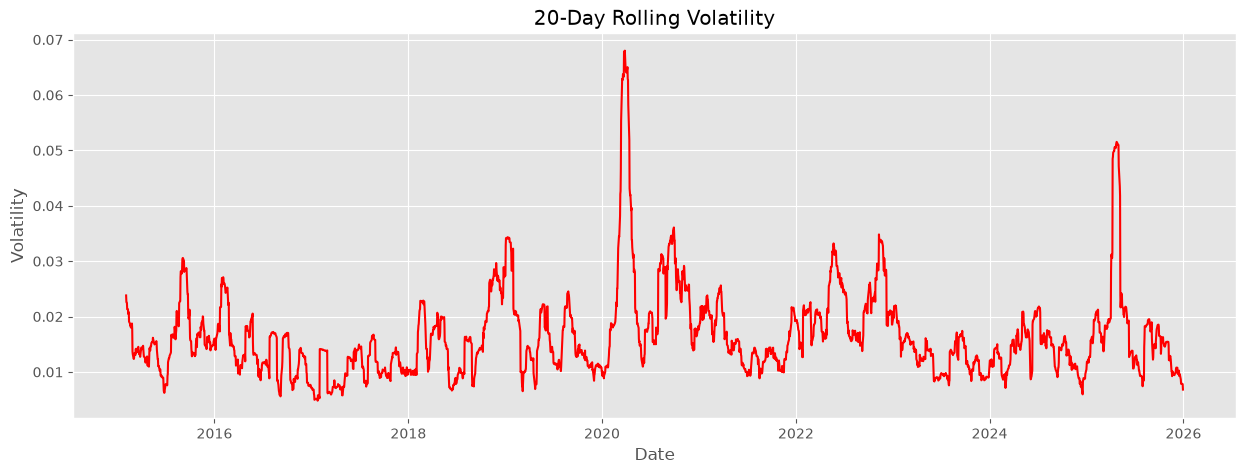

In [18]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Date"],
    df["Rolling_Volatility"],
    color="red"
)

plt.title(f"{window}-Day Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.show()

# Price-Based Feature Engineering

Price-based features capture the fundamental characteristics of market movement.

Rather than using raw prices directly, we derive statistical features that describe returns, momentum, price dispersion, and intraday behavior.

These engineered features provide more informative inputs to machine learning models than raw OHLC values alone.

In [19]:
# Simple percentage return
df["Return"] = df["Close"].pct_change()

# Log return
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

# Absolute price change
df["Price_Change"] = df["Close"] - df["Open"]

# Previous close
df["Previous_Close"] = df["Close"].shift(1)

# Overnight gap
df["Gap"] = df["Open"] - df["Previous_Close"]

# High-Low range
df["High_Low_Range"] = df["High"] - df["Low"]

# Open-Close range
df["Open_Close_Range"] = abs(df["Close"] - df["Open"])

# True Range
df["True_Range"] = np.maximum.reduce([
    df["High"] - df["Low"],
    abs(df["High"] - df["Previous_Close"]),
    abs(df["Low"] - df["Previous_Close"])
])

## Rolling Statistical Features

Financial markets exhibit local trends and volatility clustering.

Rolling statistics summarize the recent behavior of prices over a fixed historical window without introducing look-ahead bias.

In [21]:
window = CONFIG["rolling_window"]

df["Rolling_Mean"] = df["Close"].rolling(window).mean()

df["Rolling_STD"] = df["Close"].rolling(window).std()

df["Rolling_Min"] = df["Close"].rolling(window).min()

df["Rolling_Max"] = df["Close"].rolling(window).max()

df["Rolling_Median"] = df["Close"].rolling(window).median()

df["Rolling_Variance"] = df["Close"].rolling(window).var()

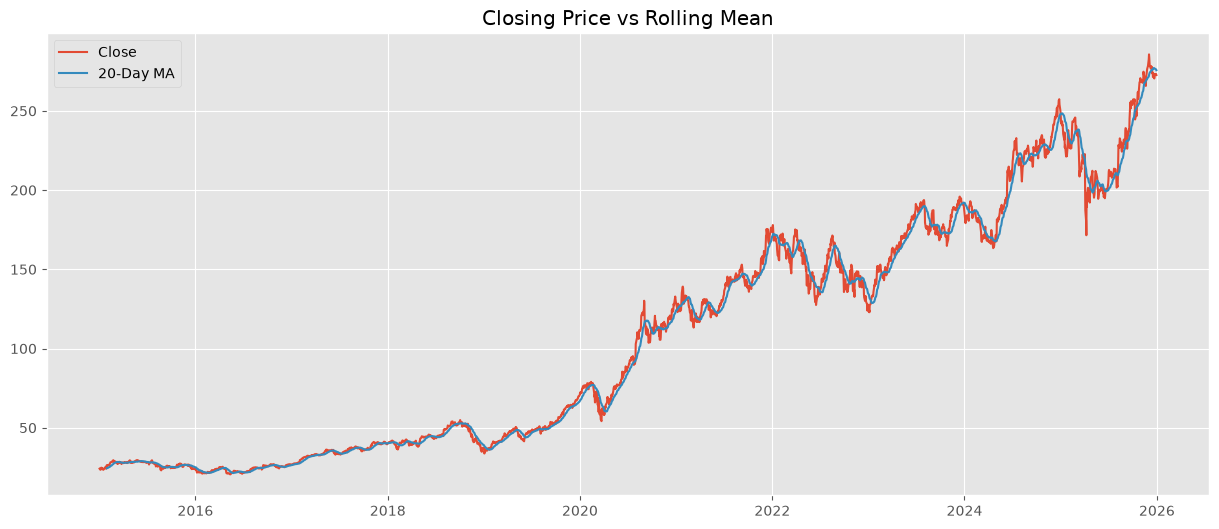

In [22]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Close"], label="Close")

plt.plot(df["Date"], df["Rolling_Mean"], label=f"{window}-Day MA")

plt.legend()

plt.title("Closing Price vs Rolling Mean")

plt.show()

## Momentum Features

Momentum measures whether prices have been moving consistently in one direction.

Momentum-based indicators are widely used in quantitative finance because trends often persist over short and medium horizons.

In [23]:
df["Momentum_5"] = df["Close"] - df["Close"].shift(5)

df["Momentum_10"] = df["Close"] - df["Close"].shift(10)

df["Momentum_20"] = df["Close"] - df["Close"].shift(20)

df["ROC_5"] = (
    df["Close"] /
    df["Close"].shift(5)
    - 1
)

df["ROC_10"] = (
    df["Close"] /
    df["Close"].shift(10)
    - 1
)

In [24]:
momentum_cols = [
    "Momentum_5",
    "Momentum_10",
    "Momentum_20",
    "ROC_5",
    "ROC_10"
]
df[momentum_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Momentum_5,2760.0,0.450745,5.027376,-50.503174,-1.116363,0.318161,2.119795,29.563797
Momentum_10,2755.0,0.901461,6.809717,-51.060211,-1.475001,0.704594,3.559158,32.010864
Momentum_20,2745.0,1.830193,9.209847,-50.423584,-1.570129,1.295135,5.901627,39.517685
ROC_5,2760.0,0.005155,0.038393,-0.227474,-0.016698,0.006429,0.027364,0.184141
ROC_10,2755.0,0.010291,0.053803,-0.229408,-0.022165,0.013235,0.044588,0.226803


In [25]:
print(f"Current Shape: {df.shape}")
print("\nCurrent Features:\n")
print(df.columns.tolist())

Current Shape: (2765, 27)

Current Features:

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Rolling_Volatility', 'Return', 'Log_Return', 'Price_Change', 'Previous_Close', 'Gap', 'High_Low_Range', 'Open_Close_Range', 'True_Range', 'Rolling_Mean', 'Rolling_STD', 'Rolling_Min', 'Rolling_Max', 'Rolling_Median', 'Rolling_Variance', 'Momentum_5', 'Momentum_10', 'Momentum_20', 'ROC_5', 'ROC_10']


# Volume Features

Price indicates *what* happened, while volume often indicates *how strongly* the market participated.

High volume generally implies stronger conviction behind a price move.

In this section we engineer features that capture trading activity, accumulation, and buying/selling pressure.

In [26]:
# Volume Moving Averages
df["Volume_MA_5"] = df["Volume"].rolling(5).mean()
df["Volume_MA_20"] = df["Volume"].rolling(20).mean()
# Relative Volume
df["Relative_Volume"] = df["Volume"] / df["Volume_MA_20"]
# Volume Change
df["Volume_Change"] = df["Volume"].pct_change()
# Volume Momentum
df["Volume_Momentum"] = df["Volume"] - df["Volume"].shift(5)

In [27]:
obv = [0]

for i in range(1, len(df)):
    if df.loc[i, "Close"] > df.loc[i - 1, "Close"]:
        obv.append(obv[-1] + df.loc[i, "Volume"])
    elif df.loc[i, "Close"] < df.loc[i - 1, "Close"]:
        obv.append(obv[-1] - df.loc[i, "Volume"])
    else:
        obv.append(obv[-1])

df["OBV"] = obv

In [28]:
typical_price = (
    df["High"] +
    df["Low"] +
    df["Close"]
) / 3

df["VWAP"] = (
    (typical_price * df["Volume"]).cumsum()
    /
    df["Volume"].cumsum()
)

In [29]:
volume_features = [
    "Volume_MA_5",
    "Volume_MA_20",
    "Relative_Volume",
    "Volume_Change",
    "Volume_Momentum",
    "OBV",
    "VWAP"
]

df[volume_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Volume_MA_5,2761.0,1.114079e+08,5.898830e+07,2.298584e+07,6.841764e+07,9.820448e+07,1.394909e+08,4.603793e+08
Volume_MA_20,2746.0,1.112565e+08,5.291661e+07,3.780050e+07,6.862236e+07,1.015564e+08,1.366388e+08,3.102953e+08
Relative_Volume,2746.0,1.001403e+00,3.692779e-01,3.191607e-01,7.703994e-01,9.129362e-01,1.129653e+00,5.245562e+00
Volume_Change,2764.0,4.984749e-02,3.579751e-01,-8.300928e-01,-1.752305e-01,-1.730897e-02,1.970188e-01,3.771993e+00
Volume_Momentum,2760.0,-3.681526e+05,6.266503e+07,-4.239080e+08,-2.338582e+07,-1.502200e+06,2.204910e+07,4.852864e+08
OBV,2765.0,3.030077e+09,2.464695e+09,-2.953755e+09,1.221714e+09,3.779836e+09,4.922009e+09,7.246397e+09
VWAP,2765.0,4.499937e+01,1.830217e+01,2.374066e+01,2.742629e+01,3.802220e+01,6.231097e+01,8.012955e+01


# Candlestick Geometry

Candlestick charts summarize intraday price movement.

Rather than assigning discrete labels such as "Hammer" or "Doji", we compute continuous geometric descriptors.

These preserve more information and allow the Transformer to learn patterns directly from data.

In [30]:
df["Body"] = abs(df["Close"] - df["Open"])

df["Upper_Wick"] = (
    df["High"] -
    np.maximum(df["Open"], df["Close"])
)

df["Lower_Wick"] = (
    np.minimum(df["Open"], df["Close"]) -
    df["Low"]
)

df["Full_Range"] = df["High"] - df["Low"]

In [31]:
eps = 1e-8

df["Body_Ratio"] = df["Body"] / (df["Full_Range"] + eps)

df["Upper_Wick_Ratio"] = (
    df["Upper_Wick"] /
    (df["Full_Range"] + eps)
)

df["Lower_Wick_Ratio"] = (
    df["Lower_Wick"] /
    (df["Full_Range"] + eps)
)

df["Body_to_Wick"] = (
    df["Body"] /
    (
        df["Upper_Wick"] +
        df["Lower_Wick"] +
        eps
    )
)

In [32]:
geometry_cols = [
    "Body",
    "Upper_Wick",
    "Lower_Wick",
    "Body_Ratio",
    "Upper_Wick_Ratio",
    "Lower_Wick_Ratio",
    "Body_to_Wick"
]

df[geometry_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Body,2765.0,1.101618,1.493862,0.0,0.190949,0.533339,1.482335,2.675862e+01
Upper_Wick,2765.0,0.549392,0.745291,0.0,0.092802,0.259179,0.740806,1.262329e+01
Lower_Wick,2765.0,0.556900,0.737415,0.0,0.098181,0.263888,0.742999,8.904357e+00
Body_Ratio,2765.0,0.463680,0.264876,0.0,0.238096,0.467337,0.688572,1.000000e+00
Upper_Wick_Ratio,2765.0,0.264283,0.207144,0.0,0.093569,0.215687,0.396395,9.382723e-01
Lower_Wick_Ratio,2765.0,0.272036,0.207115,0.0,0.099991,0.228092,0.404257,9.499979e-01
Body_to_Wick,2765.0,7740.250138,406886.050456,0.0,0.312502,0.877361,2.211020,2.139540e+07


In [34]:
print(f"Current Feature Count: {len(df.columns)}")

Current Feature Count: 42


# Volatility Features

Volatility measures the magnitude of price movement rather than its direction.

Unlike simple returns, volatility estimators capture market uncertainty and are among the most informative predictors for financial forecasting.

This section implements multiple volatility estimators commonly used in quantitative finance.

In [35]:
# Average True Range (ATR)

window = 14

df["ATR"] = (
    df["True_Range"]
    .rolling(window)
    .mean()
)

In [36]:
# Historical Volatility

window = 20

df["Historical_Volatility"] = (
    df["Log_Return"]
    .rolling(window)
    .std()
    * np.sqrt(252)
)

In [37]:
# Parkinson Volatility

window = 20

hl = np.log(df["High"] / df["Low"])

df["Parkinson_Volatility"] = np.sqrt(
    (
        hl.pow(2)
        .rolling(window)
        .mean()
    ) /
    (4 * np.log(2))
)

In [38]:
# Garman-Klass Volatility

log_hl = np.log(df["High"] / df["Low"])

log_co = np.log(df["Close"] / df["Open"])

gk = (
    0.5 * log_hl**2
    -
    (2*np.log(2)-1)
    * log_co**2
)

df["Garman_Klass"] = np.sqrt(
    gk.rolling(20).mean()
)

In [39]:
vol_cols = [
    "ATR",
    "Historical_Volatility",
    "Parkinson_Volatility",
    "Garman_Klass"
]

df[vol_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ATR,2751.0,2.446738,1.950132,0.249973,0.647814,2.263774,3.830118,13.776497
Historical_Volatility,2745.0,0.260523,0.125539,0.076283,0.179872,0.234645,0.304020,1.081182
Parkinson_Volatility,2746.0,0.013211,0.005144,0.005376,0.009827,0.012050,0.015784,0.039362
Garman_Klass,2746.0,0.013238,0.005054,0.005421,0.009988,0.012131,0.015404,0.040731


# Trend Features

Trend-following indicators smooth noisy price movements and help identify persistent market direction.

Rather than predicting future prices directly, these indicators summarize recent market behavior over different horizons.

In [40]:
df["EMA_9"] = df["Close"].ewm(span=9).mean()

df["EMA_21"] = df["Close"].ewm(span=21).mean()

df["EMA_50"] = df["Close"].ewm(span=50).mean()

df["EMA_200"] = df["Close"].ewm(span=200).mean()

In [41]:
df["MACD"] = (
    df["EMA_12"] if "EMA_12" in df.columns else df["Close"].ewm(span=12).mean()
)

df["EMA_12"] = df["Close"].ewm(span=12).mean()

df["EMA_26"] = df["Close"].ewm(span=26).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]

df["Signal"] = df["MACD"].ewm(span=9).mean()

df["MACD_Histogram"] = (
    df["MACD"] - df["Signal"]
)

In [42]:
window = 20

df["Rolling_Skew"] = (
    df["Return"]
    .rolling(window)
    .skew()
)

df["Rolling_Kurtosis"] = (
    df["Return"]
    .rolling(window)
    .kurt()
)

df["Rolling_Zscore"] = (
    df["Close"] -
    df["Rolling_Mean"]
) / (
    df["Rolling_STD"] + 1e-8
)

In [43]:
df["Rolling_Max_Return"] = (
    df["Return"]
    .rolling(window)
    .max()
)

df["Rolling_Min_Return"] = (
    df["Return"]
    .rolling(window)
    .min()
)

df["Rolling_Return_STD"] = (
    df["Return"]
    .rolling(window)
    .std()
)

# Prediction Targets

Targets are generated using only future observations.

These columns are never used as model inputs.

Later notebooks will use these variables as prediction objectives.

In [44]:
h = CONFIG["prediction_horizon"]

df["Future_Close"] = df["Close"].shift(-h)

df["Future_Return"] = (
    df["Future_Close"] -
    df["Close"]
) / df["Close"]

df["Target_Direction"] = (
    df["Future_Return"] > 0
).astype(int)

In [45]:
df[[
    "Close",
    "Future_Close",
    "Future_Return",
    "Target_Direction"
]].tail(10)

,Close,Future_Close,Future_Return,Target_Direction
2755,274.100739,271.854919,-0.008193,0
2756,271.335876,273.302216,0.007247,1
2757,271.685242,272.892975,0.004445,1
2758,273.162506,273.252350,0.000329,1
2759,270.467499,272.573578,0.007787,1
2760,271.854919,NaN,NaN,0
2761,273.302216,NaN,NaN,0
2762,272.892975,NaN,NaN,0
2763,273.252350,NaN,NaN,0
2764,272.573578,NaN,NaN,0


In [46]:
print("Shape before dropping NaNs:", df.shape)

df = df.dropna().reset_index(drop=True)

print("Shape after dropping NaNs:", df.shape)

Shape before dropping NaNs: (2765, 64)
Shape after dropping NaNs: (2740, 64)


In [47]:
df.isnull().sum().sort_values(ascending=False).head(20)

Date                  0
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
Daily_Return          0
Rolling_Volatility    0
Return                0
Log_Return            0
Price_Change          0
Previous_Close        0
Gap                   0
High_Low_Range        0
Open_Close_Range      0
True_Range            0
Rolling_Mean          0
Rolling_STD           0
Rolling_Min           0
Rolling_Max           0
dtype: int64

In [48]:
df["Day"] = df["Date"].dt.day

df["Month"] = df["Date"].dt.month

df["Quarter"] = df["Date"].dt.quarter

df["DayOfWeek"] = df["Date"].dt.dayofweek

df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

In [49]:
lags = [1, 2, 3, 5, 10]

for lag in lags:
    df[f"Close_Lag_{lag}"] = df["Close"].shift(lag)
    df[f"Return_Lag_{lag}"] = df["Return"].shift(lag)
    df[f"Volume_Lag_{lag}"] = df["Volume"].shift(lag)

In [50]:
windows = [5, 10, 20]

for w in windows:

    df[f"Rolling_High_{w}"] = (
        df["High"]
        .rolling(w)
        .max()
    )

    df[f"Rolling_Low_{w}"] = (
        df["Low"]
        .rolling(w)
        .min()
    )

    df[f"Distance_From_High_{w}"] = (
        df["Close"]
        /
        df[f"Rolling_High_{w}"]
    )

    df[f"Distance_From_Low_{w}"] = (
        df["Close"]
        /
        df[f"Rolling_Low_{w}"]
    )

In [52]:
import seaborn as sns

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr(method="spearman")

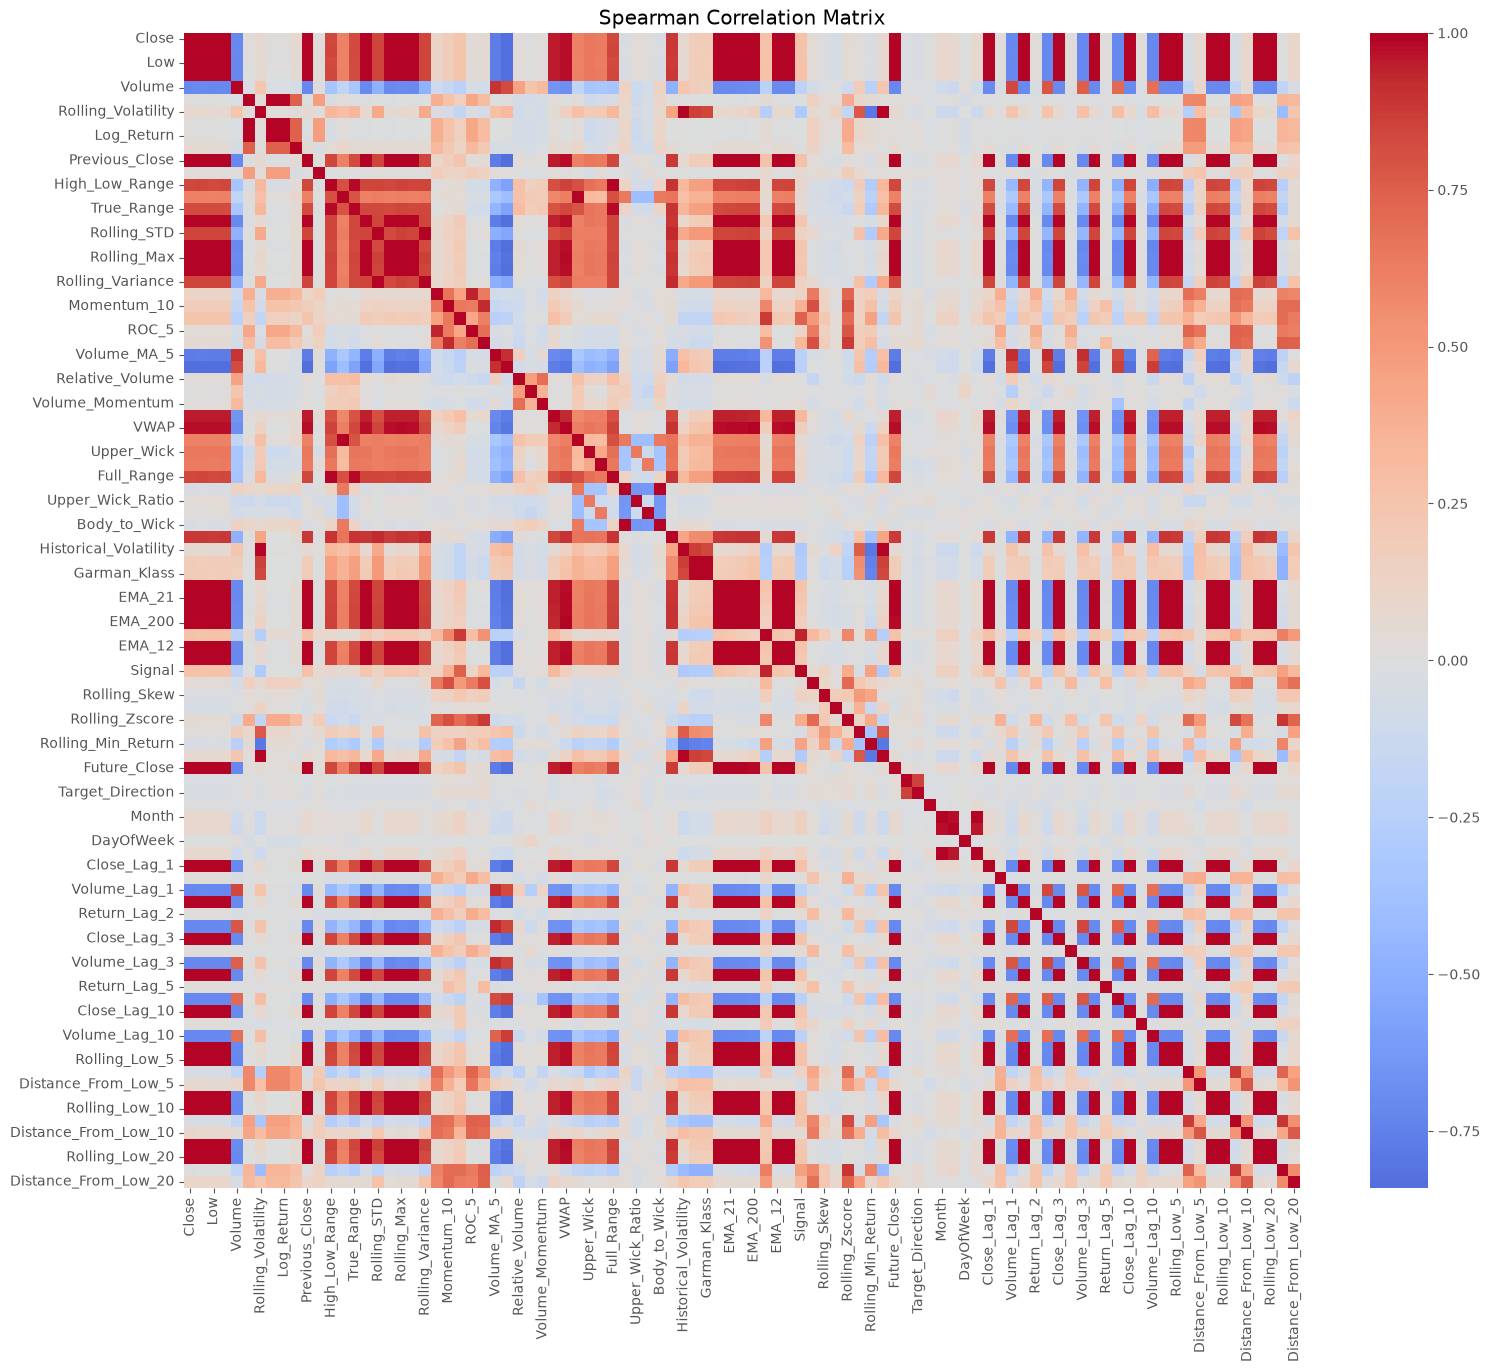

In [53]:
plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=False,
    cbar=True
)

plt.title("Spearman Correlation Matrix")

plt.show()

In [54]:
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(abs(upper[column]) > 0.95)
]

print("Highly correlated features:\n")
print(high_corr)

Highly correlated features:

['High', 'Low', 'Open', 'Return', 'Log_Return', 'Previous_Close', 'True_Range', 'Rolling_Mean', 'Rolling_Min', 'Rolling_Max', 'Rolling_Median', 'Rolling_Variance', 'OBV', 'VWAP', 'Body', 'Full_Range', 'Body_to_Wick', 'Historical_Volatility', 'Garman_Klass', 'EMA_9', 'EMA_21', 'EMA_50', 'EMA_200', 'EMA_12', 'EMA_26', 'Rolling_Return_STD', 'Future_Close', 'Quarter', 'WeekOfYear', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_10', 'Rolling_High_5', 'Rolling_Low_5', 'Rolling_High_10', 'Rolling_Low_10', 'Rolling_High_20', 'Rolling_Low_20']


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [56]:
ignore = [
    "Date",
    "Future_Close",
    "Future_Return",
    "Target_Direction"
]

features = [
    c
    for c in df.columns
    if c not in ignore
]

X = df[features]

y = df["Future_Return"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    shuffle=False,
    test_size=0.2
)

In [58]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [59]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(30)

,Feature,Importance
54,Rolling_Skew,0.039852
52,Signal,0.037436
43,Parkinson_Volatility,0.031027
57,Rolling_Max_Return,0.029100
53,MACD_Histogram,0.026692
44,Garman_Klass,0.026097
60,Day,0.024518
64,WeekOfYear,0.024361
31,OBV,0.022517
48,EMA_200,0.022487


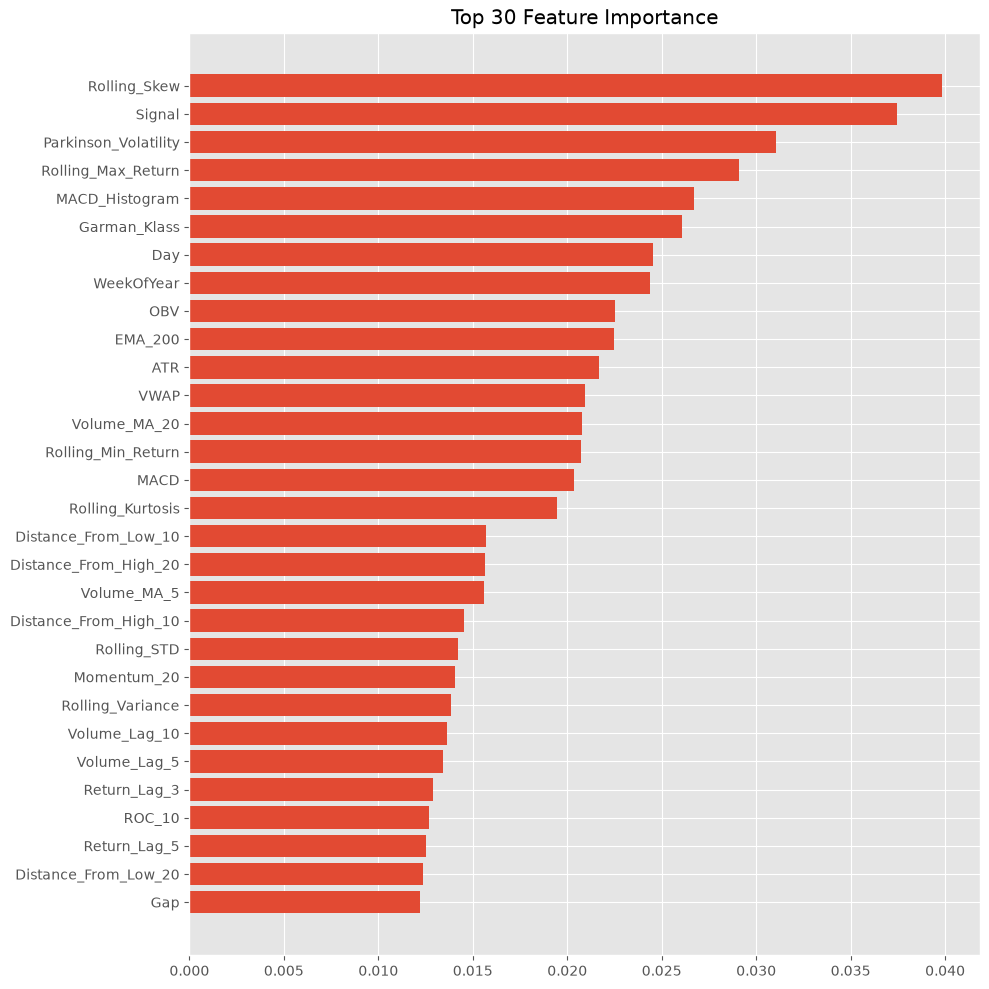

In [60]:
plt.figure(figsize=(10,10))

plt.barh(
    importance["Feature"][:30][::-1],
    importance["Importance"][:30][::-1]
)

plt.title("Top 30 Feature Importance")

plt.tight_layout()

plt.show()

In [61]:
print("="*60)

print("Dataset Summary")

print("="*60)

print(f"Rows          : {len(df)}")
print(f"Columns       : {len(df.columns)}")
print(f"Numeric Cols  : {len(df.select_dtypes(include=np.number).columns)}")
print(f"Missing Values: {df.isnull().sum().sum()}")

print("="*60)

Dataset Summary
Rows          : 2740
Columns       : 96
Numeric Cols  : 95
Missing Values: 191


In [62]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2740 entries, 0 to 2739
Data columns (total 96 columns):
 #   Column                 Non-Null Count  Dtype        
---  ------                 --------------  -----        
 0   Date                   2740 non-null   datetime64[s]
 1   Close                  2740 non-null   float64      
 2   High                   2740 non-null   float64      
 3   Low                    2740 non-null   float64      
 4   Open                   2740 non-null   float64      
 5   Volume                 2740 non-null   int64        
 6   Daily_Return           2740 non-null   float64      
 7   Rolling_Volatility     2740 non-null   float64      
 8   Return                 2740 non-null   float64      
 9   Log_Return             2740 non-null   float64      
 10  Price_Change           2740 non-null   float64      
 11  Previous_Close         2740 non-null   float64      
 12  Gap                    2740 non-null   float64      
 13  High_Low_Range         2740 n

In [63]:
import os
import json

os.makedirs("processed_data", exist_ok=True)

In [64]:
window = 20

rolling_high = df["High"].rolling(window).max()
rolling_low = df["Low"].rolling(window).min()

df["Range_Position"] = (
    (df["Close"] - rolling_low)
    /
    (rolling_high - rolling_low + 1e-8)
)

df["Distance_From_High_20"] = rolling_high - df["Close"]

df["Distance_From_Low_20"] = df["Close"] - rolling_low

df["Breakout_20"] = (
    df["Close"] > rolling_high.shift(1)
).astype(int)

df["Breakdown_20"] = (
    df["Close"] < rolling_low.shift(1)
).astype(int)

In [65]:
df = df.dropna().reset_index(drop=True)

In [66]:
df.to_csv(
    "processed_data/master_dataset.csv",
    index=False
)

df.to_parquet(
    "processed_data/master_dataset.parquet",
    index=False
)

In [67]:
feature_columns = [
    col for col in df.columns
    if col not in [
        "Date",
        "Future_Close",
        "Future_Return",
        "Target_Direction"
    ]
]

metadata = {
    "ticker": CONFIG["ticker"],
    "num_features": len(feature_columns),
    "features": feature_columns,
    "target": "Future_Return",
    "prediction_horizon": CONFIG["prediction_horizon"]
}

with open("processed_data/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [68]:
print("="*60)
print("NOTEBOOK 1 COMPLETE")
print("="*60)

print(f"Dataset Shape : {df.shape}")
print(f"Features      : {len(feature_columns)}")
print(f"Target        : Future_Return")
print(f"Ticker        : {CONFIG['ticker']}")

print("="*60)

NOTEBOOK 1 COMPLETE
Dataset Shape : (2721, 99)
Features      : 95
Target        : Future_Return
Ticker        : AAPL
